In [20]:
import sys
import os

if 'google.colab' in sys.modules:
    if not os.path.exists('/content/NLP'):
        !git clone -b lab-05 https://github.com/AndrianaNahirna/NLP.git

    %cd /content/NLP

    !pip install -r requirements.txt -q
    !git fetch origin
    !git reset --hard origin/lab-05

    sys.path.append('/content/NLP')

print("Середовище налаштовано.")

/content/NLP
HEAD is now at 12fcb51 Add split 2
Середовище налаштовано.


In [21]:
import pandas as pd

if 'google.colab' in sys.modules:
    FOLDER_ID = '1Z4ko8PYcLJOnnU98T6MTXLVYHnpMkHVK'

    # Завантаження датасету
    os.makedirs('/content/NLP/data', exist_ok=True)
    !gdown --folder https://drive.google.com/drive/folders/{FOLDER_ID} -O /content/NLP/data/

    import glob
    csv_files = glob.glob('/content/NLP/data/**/processed_v2.csv', recursive=True)

    if csv_files:
        data_path = csv_files[0]
        df = pd.read_csv(data_path)
        print(f"Датасет завантажено. Кількість рядків: {len(df)}")
    else:
        print("Файл processed_v2.csv не знайдено.")
else:
    # Локальний шлях
    df = pd.read_csv('../data/processed_v2.csv')

Retrieving folder contents
Processing file 12MwPw-0rT5kZoMFme6erhb4NeBsQxsoECoQzPuAqWcI processed_v2
Processing file 17odn4ukdHLvZKqqUuaTNPuHX66Aal-zk processed_v2.csv
Processing file 1gMJmeUiP3HXGR4P3F3Gq-eWhKkPxAbnw processed_v3_lemma.csv
Processing file 1tVj7OaRkYqaoVtmDGgDxUQ8nkDUvy7W7 raw.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=12MwPw-0rT5kZoMFme6erhb4NeBsQxsoECoQzPuAqWcI
From (redirected): https://docs.google.com/spreadsheets/d/12MwPw-0rT5kZoMFme6erhb4NeBsQxsoECoQzPuAqWcI/export?format=xlsx
To: /content/NLP/data/NLP_datasets/processed_v2
1.60MB [00:00, 77.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=17odn4ukdHLvZKqqUuaTNPuHX66Aal-zk
To: /content/NLP/data/NLP_datasets/processed_v2.csv
100% 5.67M/5.67M [00:00<00:00, 52.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gMJmeUiP3HXGR4P3F3Gq-eWhKkPxAbnw
To: /content/NLP/data/NLP_da

In [22]:
import pandas as pd
import sys
sys.path.append('../src')
from sentiment.src.split import make_splits, save_splits

#df = pd.read_csv('sentiment/data/sample/sample_raw.csv')
df = pd.read_csv('data/NLP_datasets/processed_v2.csv')
# ВКАЗІВКА ДЛЯ FULL DATA:
# Щоб відтворити цей спліт для повного датасету, достатньо змінити шлях:
# df = pd.read_csv('data/NLP_datasets/processed_v2.csv')
# і запустити комірку наново. Seed 42 гарантує ідентичний результат.
if 'processed_text' in df.columns:
    df = df.rename(columns={'processed_text': 'text'})

splits = make_splits(df, strategy="stratified", seed=42, target_col="target")

save_splits(splits, data_out_dir="sentiment/data/sample", docs_out_dir="sentiment/docs")

ID сплітів збережено у папку: sentiment/data/sample/
Маніфест збережено: sentiment/docs/splits_manifest_lab5.json


   Розподіл класів (Target) по сплітах


,Train (%),Val (%),Test (%)
target,,,
negative,63.33,63.37,63.49
positive,36.67,36.63,36.51


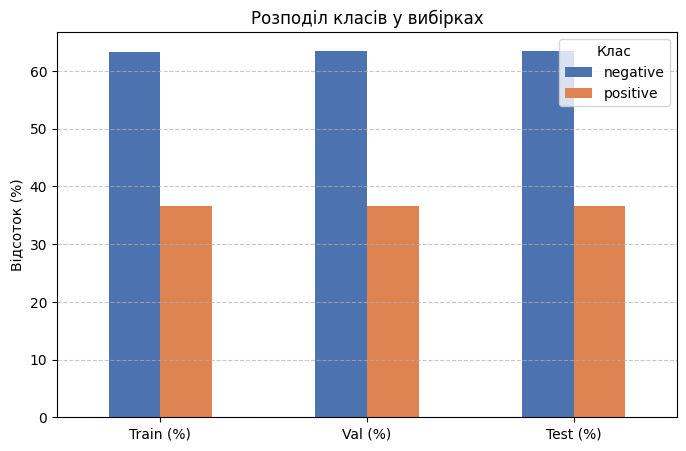


    Розподіл довжин тексту (слова)


,Train,Val,Test
Середня,160.68,162.39,163.28
Медіана,129.00,132.00,132.50
5-й перцентиль,78.00,79.00,80.00
95-й перцентиль,344.40,347.80,328.40


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

TARGET_COL = 'target'
TEXT_COL = 'text'

# Розподіл класів у train/val/test
print("   Розподіл класів (Target) по сплітах")
class_dist = pd.DataFrame({
    'Train (%)': splits['train'][TARGET_COL].value_counts(normalize=True) * 100,
    'Val (%)': splits['val'][TARGET_COL].value_counts(normalize=True) * 100,
    'Test (%)': splits['test'][TARGET_COL].value_counts(normalize=True) * 100
}).fillna(0).round(2)

display(class_dist)

class_dist.T.plot(kind='bar', figsize=(8, 5), color=['#4C72B0', '#DD8452'])
plt.title('Розподіл класів у вибірках')
plt.ylabel('Відсоток (%)')
plt.xticks(rotation=0)
plt.legend(title='Клас')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Розподіл довжин тексту
print("\n    Розподіл довжин тексту (слова)")
def get_text_stats(df, text_column):
    lengths = df[text_column].astype(str).apply(lambda x: len(x.split()))
    return {
        'Середня': lengths.mean(),
        'Медіана': lengths.median(),
        '5-й перцентиль': lengths.quantile(0.05),
        '95-й перцентиль': lengths.quantile(0.95)
    }

length_stats = pd.DataFrame({
    'Train': get_text_stats(splits['train'], TEXT_COL),
    'Val': get_text_stats(splits['val'], TEXT_COL),
    'Test': get_text_stats(splits['test'], TEXT_COL)
}).round(2)

display(length_stats)

Усі три вибірки (train, val, test) є репрезентативними та максимально схожими між собою. Завдяки використанню стратифікованого поділу, відсоток позитивних та негативних міток у всіх сплітах ідентичний. Розподіл довжин текстів також є стабільним: середні значення, медіани та 5-95 перцентилі майже не відрізняються між підвибірками. Жодних критичних перекосів, які могли б спотворити метрики, не виявлено.

In [24]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

TEXT_COL = 'text'

print("Перевірка на точні дублікати")
train_texts = set(splits['train'][TEXT_COL].dropna().str.lower().str.strip())
val_texts = set(splits['val'][TEXT_COL].dropna().str.lower().str.strip())
test_texts = set(splits['test'][TEXT_COL].dropna().str.lower().str.strip())

dup_train_test = len(train_texts.intersection(test_texts))
dup_train_val = len(train_texts.intersection(val_texts))
dup_val_test = len(val_texts.intersection(test_texts))

print(f"exact duplicates train ∩ test = {dup_train_test}")
print(f"exact duplicates train ∩ val = {dup_train_val}")
print(f"exact duplicates val ∩ test = {dup_val_test}")


print("\nПеревірка 'майже дублів'")
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_train = vectorizer.fit_transform(splits['train'][TEXT_COL].fillna(''))
tfidf_test = vectorizer.transform(splits['test'][TEXT_COL].fillna(''))
tfidf_val = vectorizer.transform(splits['val'][TEXT_COL].fillna(''))

THRESHOLD = 0.95

def find_near_duplicates(tfidf_1, tfidf_2, df_1, df_2, name_1, name_2):
    sim_matrix = cosine_similarity(tfidf_1, tfidf_2)
    idx_1, idx_2 = np.where(sim_matrix >= THRESHOLD)

    suspicious_pairs = list(zip(idx_1, idx_2))
    print(f"\nЗнайдено {len(suspicious_pairs)} підозрілих пар між {name_1} та {name_2}")

    for i, (i1, i2) in enumerate(suspicious_pairs[:5]):
        print(f"\nПриклад {i+1} (схожість: {sim_matrix[i1, i2]:.3f}) ---")
        print(f"[{name_1}]: {df_1.iloc[i1][TEXT_COL]}")
        print(f"[{name_2}]: {df_2.iloc[i2][TEXT_COL]}")

find_near_duplicates(tfidf_train, tfidf_test, splits['train'], splits['test'], "Train", "Test")
find_near_duplicates(tfidf_train, tfidf_val, splits['train'], splits['val'], "Train", "Val")


print("\nПеревірка підказок")
leakage_pattern = re.compile(r'(category:|label=|class=|topic=|позитив|негатив)', re.IGNORECASE)

def check_template_leakage(df, split_name):
    bad_rows = df[df[TEXT_COL].astype(str).str.contains(leakage_pattern, na=False)]
    print(f"\nЗнайдено {len(bad_rows)} потенційних підказок у спліті {split_name}.")

    if len(bad_rows) > 0:
        for idx, row in bad_rows.head(10).iterrows():
            print(f"[ID {idx}]: {row[TEXT_COL]}")

check_template_leakage(splits['train'], "Train")
check_template_leakage(splits['val'], "Val")
check_template_leakage(splits['test'], "Test")

Перевірка на точні дублікати
exact duplicates train ∩ test = 1
exact duplicates train ∩ val = 1
exact duplicates val ∩ test = 0

Перевірка 'майже дублів'

Знайдено 1 підозрілих пар між Train та Test

Приклад 1 (схожість: 1.000) ---
[Train]: Перший раз, і щось не зрослось. Рано-вранці (близько 05:30) оформив через сайт замовлення на планшет Іраd mіnі 5. Прийшло повідомлення, що замовлення прийнято в роботу, але оплата поки недоступна. Протягом дня час від часу заходив в особистий кабінет — замовлення в роботі, оплата недоступна. О 17:59 на Вайбер приходить повідомлення, що замовлення вже можна оплатити. І через хвилину (!), о 18:00, магазин скасовує замовлення. Причина: "Клієнт скасував замовлення через особистий кабінет". У мене одне запитання: що це було? Запитання риторичне. На не чекаю. Зрештою, стадіон так стадіон. Якщо вам не потрібні мої гроші, віддам їх іншому магазину, де вміють цінувати клієнта і його час.
[Test]: Перший раз, і щось не зрослось. Рано-вранці (близько 05:30) офо

/tmp/ipykernel_331/797950347.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  bad_rows = df[df[TEXT_COL].astype(str).str.contains(leakage_pattern, na=False)]



Знайдено 241 потенційних підказок у спліті Train.
[ID 2628]: Попередній замовлений тв виявився бракованим, і за допомогою відділу якості магазину (спасибі їм велике) тв обміняли, на більш дорогий, з моєю доплатою. Погано тільки те, що другий телевізор доставили до під'їзду, тобто перевірити товар можливості не було. На свій страх і ризик (невиправданий) забрав у кур'єра неперевірений тв. Розпакував, включив - відразу видно досить сильні засвітки, 1 битий піксель. В цілому, наявність засветов на жк тв в темряві - це нормально, але тут явний брак, ліхтарі по кутах видно навіть при мінімальній підсвічуванню. Хоч це і зовсім не те, що очікуєш побачити купуючи один з топових тв, все-таки вирішив почекати тиждень, раптом пройде. Тиждень минув - проблема не зникла, знову потрібно робити повернення. Ось тут у стилуса починаються проблеми - менеджери магазину перенаправляють в сервісний центр, а в сервісний центр з 20 спроб додзвонитися зміг 1 раз. Попросив організувати доставку товару на пове

/tmp/ipykernel_331/797950347.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  bad_rows = df[df[TEXT_COL].astype(str).str.contains(leakage_pattern, na=False)]
/tmp/ipykernel_331/797950347.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  bad_rows = df[df[TEXT_COL].astype(str).str.contains(leakage_pattern, na=False)]



Знайдено 27 потенційних підказок у спліті Test.
[ID 2519]: Проблеми з сервісним центом і гарантією. 03.02.2013 в вашому магазині був куплений sоnу хреrіа аrсо s whіtе (lt26w), І вже 18.02 я звернувся в ваш сервісний центр, оскільки біля телефону перестав працювати екран. У гарантійному обслуговуванні мені було відмовлено, акт <ID>. Відмова мотивувалася "... в зв'язку з потрапляння вологи в телефон". Розібрати телефон для підтвердження своїх слів в сервіс центрі відмовилися. Тому - "попадання вологи в телефон" це безпідставна формулювання. Та й приймальник в сервісі у вас викликав виключно негативні емоції. Відмова в сервісі мотивували тим що лакмусовий папір біля гнізда для навушників червона, а повинна бути біла. заявлено що хреrіа аrсо s водостійкий телефон і отже датчик затоки зовні. Подивився у знайомих на робочих телефонах - папір у коннектора навушників теж червоного кольору. Виходить що насправді гарантії на телефон немає! Папірець яка йшла з телефоном не є офіційною гарантією.

In [25]:
import os

docs_dir = 'sentiment/docs'
os.makedirs(docs_dir, exist_ok=True)

# 1. Оновлений Audit Summary
audit_summary_text = """# Audit Summary: Lab 5 (Split & Leakage Checks)

**Дата:** 2026-03-13
**Вхідні дані:** `processed_v2.csv` (Повний набір даних)
**Статус:** Виявлено незначний витік даних (Duplicate Leakage), потребує очищення перед навчанням.

**Ключові результати:**
1. **Спліт:** Дані розділено за стратегією Stratified random split (80/10/10) із зафіксованим `seed=42`.
2. **Баланс:** Пропорції класів ідеально збережено у всіх підвибірках: ~63.4% `negative` та ~36.6% `positive`. Розподіл довжин текстів стабільний (медіана ~130 слів).
3. **Витоки (Leakage):**
   - **Точні дублікати:** Знайдено витік! 1 дублікат між train та test, 1 дублікат між train та val.
   - **Майже дублі (Near-duplicates):** Ті самі 2 пари з косинусною схожістю 1.000.
   - **Підказки (Template leakage):** Спрацювання є (241 у train), але ручний аналіз показав, що це хибнопозитивні результати (природне вживання слів "позитив/негатив" користувачами).

**Висновок:** Спліт виконано якісно з точки зору балансу класів. Однак наявність дублікатів між вибірками вимагає додаткового етапу очищення (видалення цих двох записів з тренувальної вибірки) перед подачею даних у ML-модель.
"""

with open(os.path.join(docs_dir, 'audit_summary_lab5.md'), 'w', encoding='utf-8') as f:
    f.write(audit_summary_text)


# 2. Оновлений Leakage Risk Report згідно з вимогами ЛР
leakage_report_text = """# Звіт щодо ризиків витоку даних (Leakage Risk Report)

## 1. Стратегія split (яка і чому)
Для розділення датасету було обрано стратегію Stratified random split у пропорції 80/10/10. Цей вибір зумовлений задачею бінарної класифікації тональності, де наявно дисбаланс класів (~63% негативних та ~37% позитивних). Стратифікація запобігає ризику Target distribution skew (спотворення розподілу цільової змінної), гарантуючи ідентичне співвідношення класів у тренувальній, валідаційній та тестовій вибірках. Проте, ця стратегія не захищає від дублікатів, що було підтверджено під час перевірок.

## 2. Статистика сплітів
* **Розміри вибірок:** Train — 80%, Val — 10%, Test — 10%.
* **Баланс класів:** У всіх трьох вибірках чітко збережено пропорцію: 63.3-63.4% класу `negative` та 36.5-36.6% класу `positive`.
* **Довжина текстів:** Розподіл стабільний. Середня довжина близько 160-163 слів, медіана — 129-132 слова.

## 3. Leakage checks results
* **exact duplicates:** train∩test = 1, train∩val = 1, val∩test = 0.
* **near-duplicates:** 2 підозрілі пари (косинусна схожість 1.000), які відповідають точним дублікатам.
* **template leakage:** Виявлено спрацювання шаблону (241 у train, 34 у val, 27 у test), але ручний перегляд довів, що це природна лексика ("позитивні емоції", "негативний відгук"). Технічних метаданих немає.
* **group leakage:** Не перевірялося (відсутні ідентифікатори авторів).
* **time leakage:** Не перевірялося (відсутні часові мітки `date`).

## 4. Ризики, що залишились
* **Group Leakage:** Відсутність ID користувачів не дозволяє виключити ризик того, що один автор залишив кілька відгуків, які потрапили в різні спліти.
* **Data Drift:** Відсутність дат унеможливлює відслідковування зміни лексики з часом.

## 5. Що ви зробите далі
* Видалити виявлені дублікати (2 тексти) з тренувальної вибірки, щоб вони не перетиналися з val та test наборами.
* Налаштувати пайплайн з використанням Logistic Regression, де `fit` векторизатора застосовуватиметься виключно до очищеної тренувальної вибірки.
"""

with open(os.path.join(docs_dir, 'leakage_risk_report_lab5.md'), 'w', encoding='utf-8') as f:
    f.write(leakage_report_text)

print(f"Файли згенеровано у папці: {docs_dir}/")

Файли згенеровано у папці: sentiment/docs/
